In [ ]:
# !pip install -U transformers
# !pip install -U datasets
# !pip install evaluate rouge_score sacrebleu


In [2]:
import pandas as pd
import time
import numpy as np
import torch
import evaluate
import os
from datasets import Dataset, load_dataset, concatenate_datasets
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq,  # QUAN TRỌNG: Dùng cho Evaluation ROUGE
)
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# Tải và Tiền xử lý Data

In [3]:
# ds = load_dataset("AI-MO/NuminaMath-CoT")
ds = load_dataset("5CD-AI/Vietnamese-395k-meta-math-MetaMathQA-gg-translated")
ds = ds["train"].to_pandas()


## Data Validation

### Handle missing values

In [4]:
res = [
    i
    for i, data in ds.iterrows()
    if len(data["query_vi"]) == 0 or len(data["response_vi"]) == 0
]
ds.drop(res, inplace=True)


## EDA

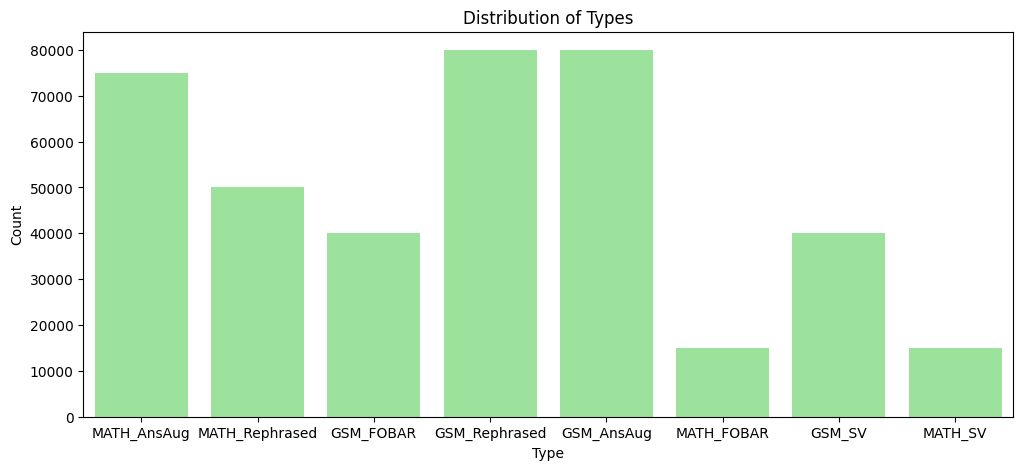

In [5]:
# Thêm cột response_len
response_queries = ds["response_vi"]
ds["response_len"] = [len(response) for response in response_queries]

# Thêm cột query_len
vi_queries = ds["query_vi"]
ds["query_len"] = [len(query) for query in vi_queries]

plt.figure(figsize=(12, 5))
sns.countplot(x="type", data=ds, color="lightgreen")
plt.title("Distribution of Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


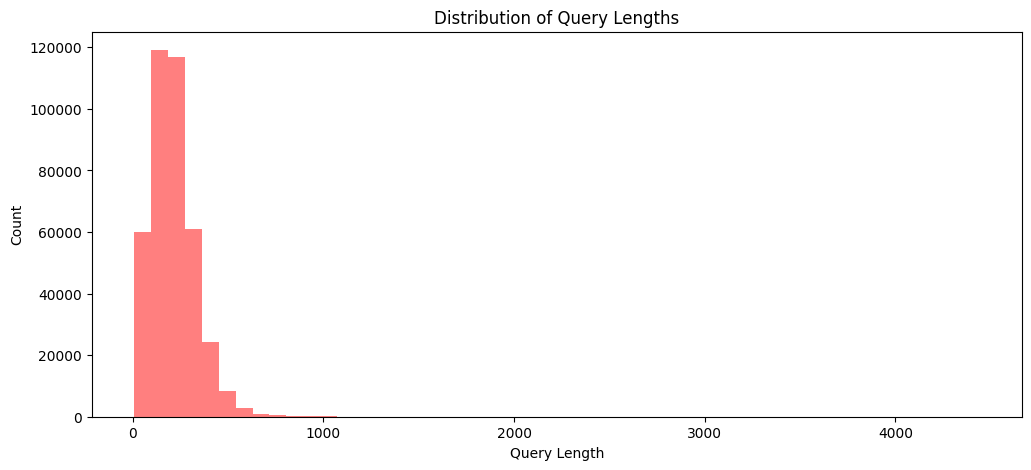

In [6]:
plt.figure(figsize=(12, 5))
plt.hist(ds["query_len"], bins=50, color="red", alpha=0.5)
plt.title("Distribution of Query Lengths")
plt.xlabel("Query Length")
plt.ylabel("Count")
plt.show()


### Drop outliers

In [7]:
def drop_outliers(df, column, lower_quantile=0.01, upper_quantile=0.99):
    q_low = df[column].quantile(lower_quantile)
    q_high = df[column].quantile(upper_quantile)
    df_filtered = df[(df[column] >= q_low) & (df[column] <= q_high)]
    return df_filtered


In [8]:
ds = drop_outliers(ds, "response_len", lower_quantile=0.05, upper_quantile=0.95)
ds = drop_outliers(ds, "query_len", lower_quantile=0.05, upper_quantile=0.95)


### Drop duplicates

In [9]:
ds.drop_duplicates(subset=["query_vi", "response_vi"], inplace=True)
print(f"Dataset đã xử lý xong. Tổng số mẫu: {len(ds)}")


Dataset đã xử lý xong. Tổng số mẫu: 313400


# Data Preprocessing (Cập nhật)

Đây là hàm `prepare_data` giống như file `full.ipynb`. Nó sẽ tạo ra 3 bộ:
1.  `ds_train_for_loss` (Không dùng ở file này)
2.  `ds_eval_for_loss` (Không dùng ở file này)
3.  `ds_eval_for_rouge` (**sẽ dùng** bộ này)

In [10]:
def prepare_data(
    ds,
    tokenizer,
    max_length: int = 512,
    max_length_prompt: int = 400,
    max_length_label: int = 112,
    batch_size: int = 1000,
    tools=None,
    num_proc: int = 4,
    test_size: float = 0.2,
    seed: int = 42,
):
    """
    Tách và xử lý data cho cả Training (tính loss) và Evaluation (tính ROUGE).
    """

    # --- 3a. Hàm con cho TRAINING (Để tính loss) ---
    def _format_and_tokenize_train(examples):
        messages_batch = [
            [
                {
                    "role": "system",
                    "content": "Please reason step by step, and give your final answer.",
                },
                {"role": "user", "content": query},
                {"role": "assistant", "content": response},
            ]
            for query, response in zip(examples["query_vi"], examples["response_vi"])
        ]
        formatted_texts = tokenizer.apply_chat_template(
            messages_batch, tokenize=False, add_generation_prompt=False
        )
        tokenized = tokenizer(
            formatted_texts,
            padding=False,
            truncation=True,
            max_length=max_length,
        )
        # BẮT BUỘC: Thêm dòng này để DataCollatorForLanguageModeling hoạt động
        tokenized["labels"] = tokenized["input_ids"].copy()
        return tokenized

    # --- 3b. Hàm con cho EVALUATION (Để tính ROUGE) ---
    def _format_and_tokenize_eval(examples):
        prompts_batch = [
            [
                {
                    "role": "system",
                    "content": "Please reason step by step, and give your final answer.",
                },
                {"role": "user", "content": query},
            ]
            for query in examples["query_vi"]
        ]
        inputs = tokenizer.apply_chat_template(
            prompts_batch,
            tokenize=True,
            padding=False,
            truncation=True,
            max_length=max_length_prompt,
            add_generation_prompt=True,
        )
        labels = tokenizer(
            text_target=examples["response_vi"],
            padding=False,
            truncation=True,
            max_length=max_length_label,
        )["input_ids"]
        return {"input_ids": inputs, "labels": labels}

    # --- 3c. Convert, Shuffle + Split ---
    if isinstance(ds, pd.DataFrame):
        ds = Dataset.from_pandas(ds)
    ds = ds.shuffle(seed=seed)
    ds_splits = ds.train_test_split(test_size=test_size, seed=seed)
    ds_train_raw = ds_splits["train"]
    ds_eval_raw = ds_splits["test"]

    # --- 3d. Map (Tạo 2 bộ dataset với 2 logic khác nhau) ---
    # (chạy cả 3 để đảm bảo tính nhất quán, nhưng chỉ dùng _for_rouge)
    print("Bắt đầu tokenizing training dataset (cho training loss)...")
    ds_train_for_loss = ds_train_raw.map(
        _format_and_tokenize_train,
        batched=True,
        batch_size=batch_size,
        num_proc=num_proc,
        remove_columns=ds.column_names,
    )
    print("Bắt đầu tokenizing evaluation dataset (cho training loss)...")
    ds_eval_for_loss = ds_eval_raw.map(
        _format_and_tokenize_train,  # Dùng chung logic train
        batched=True,
        batch_size=batch_size,
        num_proc=num_proc,
        remove_columns=ds.column_names,
    )
    print("Bắt đầu tokenizing evaluation dataset (cho ROUGE)...")
    ds_eval_for_rouge = ds_eval_raw.map(
        _format_and_tokenize_eval,
        batched=True,
        batch_size=batch_size,
        num_proc=num_proc,
        remove_columns=ds.column_names,
    )

    return ds_train_for_loss, ds_eval_for_loss, ds_eval_for_rouge


# Cấu hình Model và Tải Tokenizer

In [11]:
class Config:
    # Training settings
    OUTPUT_DIR = "./output_1"
    LOGGING_DIR = "./logs"
    EPOCHS = 1
    BATCH_SIZE = 2
    PER_DEVICE_EVAL_BATCH_SIZE = 128
    GRADIENT_ACCUMULATION_STEPS = 32
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 0.05
    MAX_GRAD_NORM = 0.4
    WARMUP_RATIO = 0.03
    MAX_LEN = 512  # Dùng cho training

    # Evaluation and saving
    SAVE_STRATEGY = "steps"
    EVAL_STRATEGY = "steps"
    EVAL_STEPS = 700
    SAVE_STEPS = 700
    SAVE_TOTAL_LIMIT = 3
    LOGGING_STEPS = 10
    MAX_STEPS = -1

    # Mixed precision
    FP16 = False
    BF16 = True

    # Other settings
    LR_SCHEDULER_TYPE = "constant_with_warmup"
    REPORT_TO = "none"  # Đổi sang "none" vì đây là file eval
    LOAD_BEST_MODEL_AT_END = True
    METRIC_FOR_BEST_MODEL = "eval_loss"
    GREATER_IS_BETTER = False
    EVAL_ACCUMULATION_STEPS = 16
    GROUP_BY_LENGTH = True


In [12]:
# (Code của class Config...)
cfg = Config()

# --- Tải Tokenizer ---
base_model_name = "Qwen/Qwen2.5-Math-1.5B"
tokenizer = AutoTokenizer.from_pretrained(
    base_model_name,
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Đã gán pad_token = eos_token")

tokenizer.padding_side = "left"


# Xử lý Data

In [13]:
# Chạy hàm prepare_data để lấy bộ eval_ds_rouge
# không cần train_ds_loss và eval_ds_loss ở đây
print("Đang xử lý data...")
_, _, eval_ds_rouge = prepare_data(
    ds,
    tokenizer,
    max_length=cfg.MAX_LEN,
    test_size=0.2,  # Giữ nguyên test_size để đảm bảo tính nhất quán
    seed=42,
)

print(f"Hoàn tất. Sẵn sàng đánh giá trên {len(eval_ds_rouge)} mẫu.")


Đang xử lý data...
Bắt đầu tokenizing training dataset (cho training loss)...


Map (num_proc=4):   0%|          | 0/250720 [00:00<?, ? examples/s]

Bắt đầu tokenizing evaluation dataset (cho training loss)...


Map (num_proc=4):   0%|          | 0/62680 [00:00<?, ? examples/s]

Bắt đầu tokenizing evaluation dataset (cho ROUGE)...


Map (num_proc=4):   0%|          | 0/62680 [00:00<?, ? examples/s]

Hoàn tất. Sẵn sàng đánh giá trên 62680 mẫu.


# 🚀 Bắt đầu Đánh giá Model

Đây là nơi bạn load model base hoặc model đã fine-tune để đánh giá.

In [14]:
# --- 1. CHỌN MODEL ĐỂ ĐÁNH GIÁ ---
# Bỏ comment 1 trong 2 dòng sau:

# Lựa chọn 1: Đánh giá BASE MODEL
MODEL_PATH_TO_EVALUATE = "Qwen/Qwen2.5-Math-1.5B"
print(f"Đang tải BASE MODEL: {MODEL_PATH_TO_EVALUATE}")

# Lựa chọn 2: Đánh giá MODEL ĐÃ FINE-TUNE
# (Giả sử bạn đã chạy trainer.train() và model tốt nhất được lưu ở OUTPUT_DIR)
# MODEL_PATH_TO_EVALUATE = cfg.OUTPUT_DIR
# print(f"Đang tải FINE-TUNED MODEL: {MODEL_PATH_TO_EVALUATE}")


# --- 2. Tải Model ---
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH_TO_EVALUATE,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
model.config.use_cache = False  # Tắt cache khi evaluate
print("Tải model hoàn tất.")


Đang tải BASE MODEL: Qwen/Qwen2.5-Math-1.5B


`torch_dtype` is deprecated! Use `dtype` instead!


Tải model hoàn tất.


In [15]:
# Cấu hình lại generation_config để tránh cảnh báo max_new_tokens vs max_length
gen_cfg = model.generation_config
gen_cfg.max_new_tokens = None  # chúng ta sẽ dùng max_length
gen_cfg.max_length = cfg.MAX_LEN  # 512
model.generation_config = gen_cfg


## Thiết lập Metric ROUGE / F1

In [16]:
print("Đang tải metric ROUGE...")
rouge_metric = evaluate.load("rouge")


Đang tải metric ROUGE...


## Hàm Compute Metrics

In [17]:
def compute_metrics_rouge(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    # Decode predictions (văn bản model sinh ra)
    preds[preds == -100] = tokenizer.pad_token_id
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # Decode labels (văn bản tham chiếu)
    labels[labels == -100] = tokenizer.pad_token_id
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Tính ROUGE
    result = rouge_metric.compute(
        predictions=decoded_preds, references=decoded_labels, use_stemmer=True
    )

    # Trích xuất F1-score (fmeasure)
    result_final = {
        "rouge1_f1": result["rouge1"].mid.fmeasure,
        "rouge2_f1": result["rouge2"].mid.fmeasure,
        "rougeL_f1": result["rougeL"].mid.fmeasure,
    }

    # Tính độ dài trung bình
    prediction_lens = [
        np.count_nonzero(pred != tokenizer.pad_token_id) for pred in preds
    ]
    result_final["gen_len"] = np.mean(prediction_lens)
    return {k: round(v, 4) for k, v in result_final.items()}


## Data Collator (BẮT BUỘC dùng Seq2Seq)

In [18]:
# Collator này sẽ xử lý `input_ids` (prompt) và `labels` (response) riêng biệt
data_collator_rouge = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    padding="longest",
)


## Training Arguments (Tối giản, chỉ để evaluate)

In [19]:
args_rouge = TrainingArguments(
    output_dir="./evaluation_results_rouge",  # Thư mục tạm để lưu kết quả
    per_device_eval_batch_size=cfg.PER_DEVICE_EVAL_BATCH_SIZE,
    bf16=cfg.BF16,
    report_to="none",
    # --- CỰC KỲ QUAN TRỌNG ---
    # Bắt buộc Trainer dùng model.generate() để sinh text
    # predict_with_generate=True,
    # generation_max_length=cfg.MAX_LEN,  # Giới hạn độ dài sinh
    # Cần thiết vì prepare_data không xóa cột gốc
    remove_unused_columns=False,
)


## Khởi tạo Trainer

In [20]:
trainer_rouge = Trainer(
    model=model,  # Model đã load (base hoặc fine-tuned)
    args=args_rouge,
    eval_dataset=eval_ds_rouge,  # Dùng bộ eval đã format cho ROUGE
    data_collator=data_collator_rouge,  # Dùng collator ROUGE
    compute_metrics=compute_metrics_rouge,  # Dùng hàm metric ROUGE
    processing_class=tokenizer,
)


The model is already on multiple devices. Skipping the move to device specified in `args`.


# 📊 Chạy Đánh giá ROUGE / F1

In [ ]:
import math

# =========================
#   EVALUATION THEO BATCH
# =========================

EVAL_BATCH_SIZE = cfg.PER_DEVICE_EVAL_BATCH_SIZE

# Tùy chọn: giới hạn số mẫu để eval cho nhanh (None = dùng hết)
MAX_EVAL_SAMPLES = None  # ví dụ: 1000 nếu muốn chỉ eval 1000 mẫu

if MAX_EVAL_SAMPLES is not None and MAX_EVAL_SAMPLES < len(eval_ds_rouge):
    eval_ds_eval = eval_ds_rouge.select(range(MAX_EVAL_SAMPLES))
else:
    eval_ds_eval = eval_ds_rouge

eval_dataloader = DataLoader(
    eval_ds_eval,
    batch_size=EVAL_BATCH_SIZE,
    collate_fn=data_collator_rouge,
    pin_memory=torch.cuda.is_available(),
    num_workers=0,
)

model.eval()

# Sử dụng metric ROUGE theo kiểu add_batch để giảm memory & gọn code
rouge_metric = evaluate.load("rouge")

print(
    f"Bắt đầu đánh giá theo batch trên {len(eval_ds_eval)} mẫu "
    f"(batch_size = {EVAL_BATCH_SIZE})..."
)
start_time = time.time()

for batch in tqdm(eval_dataloader, desc="Evaluating (batched ROUGE)"):
    with torch.no_grad():
        # Đưa input lên device
        input_ids = batch["input_ids"].to(model.device)
        attention_mask = batch["attention_mask"].to(model.device)

        # Generate theo BATCH (KHÔNG truyền max_length/max_new_tokens nữa,
        # đã set sẵn trong generation_config)
        generated_tokens_full = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pad_token_id=tokenizer.eos_token_id,
        )

        # Cắt bỏ phần prompt, chỉ giữ token mới sinh
        generated_tokens_new = generated_tokens_full[:, input_ids.shape[1] :]

        # Decode predictions theo BATCH
        decoded_preds = tokenizer.batch_decode(
            generated_tokens_new, skip_special_tokens=True
        )

        # Xử lý labels: thay -100 bằng pad_token_id rồi decode
        labels = batch["labels"].clone()
        labels[labels == -100] = tokenizer.pad_token_id
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

        # Strip khoảng trắng dư
        decoded_preds = [p.strip() for p in decoded_preds]
        decoded_labels = [l.strip() for l in decoded_labels]

        # Thêm batch này vào metric (prediction vs reference)
        rouge_metric.add_batch(
            predictions=decoded_preds,
            references=decoded_labels,
        )

end_time = time.time()
total_eval_time = end_time - start_time
num_eval_samples = len(eval_ds_eval)
samples_per_sec = (
    num_eval_samples / total_eval_time if total_eval_time > 0 else float("inf")
)

print("Đánh giá hoàn tất.")

# TÍNH ROUGE: chỉ lấy F1 và một score tổng
rouge_results = rouge_metric.compute(
    use_stemmer=True,
    rouge_types=["rouge1", "rouge2", "rougeL"],
)

rouge1_f1 = rouge_results["rouge1"].mid.fmeasure
rouge2_f1 = rouge_results["rouge2"].mid.fmeasure
rougeL_f1 = rouge_results["rougeL"].mid.fmeasure

# Score tổng (F1 trung bình 3 loại ROUGE)
rouge_mean_f1 = (rouge1_f1 + rouge2_f1 + rougeL_f1) / 3.0

print("\n====== 📊 KẾT QUẢ ROUGE (BATCHED) ======")
print(f"Model: {MODEL_PATH_TO_EVALUATE}")
print(f"Tổng số mẫu: {num_eval_samples}")
print(f"Tổng thời gian: {total_eval_time:.2f} giây")
print(f"Tốc độ: {samples_per_sec:.2f} samples/giây")

print("\n--- ROUGE F1 ---")
print(f"  ROUGE-1 F1: {rouge1_f1:.4f}")
print(f"  ROUGE-2 F1: {rouge2_f1:.4f}")
print(f"  ROUGE-L F1: {rougeL_f1:.4f}")
print(f"\n>>> ROUGE MEAN F1 (score tổng): {rouge_mean_f1:.4f}")


Bắt đầu đánh giá theo batch trên 62680 mẫu (batch_size = 128)...


Evaluating (batched ROUGE):   0%|          | 0/490 [00:00<?, ?it/s]